# TRGB Distance Ladder: From Distances to H₀

This notebook converts your TRGB distance measurements into a Hubble constant H₀.

## Structure

| Section | What it does |
|---------|-------------|
| **Background** | Mathematical derivation of the distance ladder |
| **Part 1 — Your TRGB H₀** | Load your TRGB results and compute H₀ |
| **Appendix — SH0ES comparison** | Same pipeline with published SH0ES Cepheid distances (Riess et al. 2022), for comparison |

## How the solver works

`mu_to_H0.py` takes your host-galaxy distance moduli μ as input and fits two parameters simultaneously using the full SN covariance matrix:
- **M_B** — the SN Ia absolute magnitude
- **H₀** — the Hubble constant

Calibrator SNe pin M_B through your measured host distances; Hubble-flow SNe then fix H₀ via Hubble's law.

## Data files

| File | Contents |
|------|----------|
| `data/TRGB_y.npy` | SN magnitude observables (TRGB-consistent selection) |
| `data/TRGB_C.npy` | Full SN covariance matrix |
| `data/TRGB_labels.csv` | Row metadata — label, type (CAL/HF), host |

Built by `data/build_cats_sn_dataset.py` from Pantheon+SH0ES (Scolnic et al. 2022).
40 calibrator hosts: all SH0ES R22 hosts plus NGC 1316, NGC 1404, NGC 4526 (added from Hoyt et al. 2023).
The appendix reloads the original SH0ES R22 partial dataset (`data/SH0ES22_partial_*`) to demonstrate a Cepheid-based measurement, for educational purposes only.


---

## Background: From Distances to H₀

### Hubble's law and the distance modulus

The Hubble constant is defined as velocity per distance. Combining it with the
distance modulus and a higher-order redshift–velocity expansion (Visser 2004;
Riess et al. 2022):

$$
\begin{cases}
H_0 \equiv v\,[\mathrm{km/s}]\cdot d^{-1}\,[\mathrm{Mpc}] \\
\mu \equiv m - M = 5\log_{10}\!\dfrac{d}{10\,\mathrm{pc}} \\
z \approx v/c \quad (z \ll 1)
\end{cases}
$$

Rewriting in parsecs and taking a logarithm:

$$5\log_{10} H_0 = 5\log_{10}(cz\{\}) - (m - M) + 25$$

where $cz\{\}$ denotes the redshift–velocity relation including higher-order kinematic terms.

### The two-rung system

This gives a linear system with two unknowns, $M_B$ and $5\log_{10}H_0$:

$$
\begin{cases}
m_{\mathrm{SN,\,calib}} &= \mu_{\mathrm{host}} + M_B & \text{(calibrator rung)} \\
m_{\mathrm{SN,\,HF}} - 5\log_{10}cz\{\} - 25 &= M_B - 5\log_{10} H_0 & \text{(Hubble-flow rung)}
\end{cases}
$$

The left-hand sides are the observed quantities assembled into the **y vector**.
Covariances between those observations are given by the matrix **C**.

The first-rung distance $\mu_{\mathrm{host}}$ — from TRGB (this challenge) or
Cepheids (SH0ES, appendix) — enters as a known input. In a full analysis,
covariances between the three rungs would be propagated; here they are omitted
for transparency.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mu_to_H0 import solve_H0, calibrator_hosts

# TRGB-consistent SN dataset (40 calibrator hosts, CATS-style HF selection).
# Built by data/build_cats_sn_dataset.py.
# To switch to the SH0ES R22 partial, change to data/SH0ES22_partial_*.
y      = np.load('data/TRGB_y.npy')
C      = np.load('data/TRGB_C.npy')
labels = pd.read_csv('data/TRGB_labels.csv')

cal = labels[labels['type'] == 'CAL']
hf  = labels[labels['type'] == 'HF']
print(f'Loaded SN dataset: {len(cal)} calibrator obs, {len(hf)} Hubble-flow SNe, '
      f'{cal["host"].nunique()} calibrator hosts.')


Loaded SN dataset: 82 calibrator obs, 496 Hubble-flow SNe, 40 calibrator hosts.


---

## Part 1: Your TRGB Measurement

The cell below reads `trgb_results.csv` produced by the TRGB notebook.
Galaxies you have not yet measured are set to NaN and automatically dropped from the fit.

### Quality filtering

If `trgb_results.csv` contains a `tip_contrast` column (written by the Section 9 export or batch mode), measurements below `MIN_TIP_CONTRAST` are excluded from the H₀ fit.

| Contrast | Interpretation |
|----------|---------------|
| > 3 | Clean detection — use |
| 2–3 | Marginal — inspect diagnostic plot before trusting |
| < 2 | Unreliable — do not use |

Excluded measurements are left as NaN (equivalent to not having measured that galaxy).
Set `MIN_TIP_CONTRAST = 0` to disable the filter.

> **Why this matters:** a spurious TRGB detection (e.g. latching onto AGB stars above the true tip) produces a distance modulus that is too small, making the galaxy appear closer than it is and inflating H₀. Low tip contrast is the primary diagnostic for such failures.


In [2]:
import os

RESULTS_CSV = os.path.join('..', 'trgb_results.csv')

# Minimum tip contrast to accept a measurement. Set to 0 to disable.
MIN_TIP_CONTRAST = 3.0

all_hosts = calibrator_hosts(labels)
mu_host_trgb       = {h: np.nan for h in all_hosts}
sigma_mu_host_trgb = {h: np.nan for h in all_hosts}

if not os.path.exists(RESULTS_CSV):
    print(f"Results file not found: {os.path.abspath(RESULTS_CSV)}")
    print("Run the TRGB notebook and export your results first (Section 9 or batch mode).")
else:
    trgb_df = pd.read_csv(RESULTS_CSV)
    skipped, low_contrast = [], []

    for _, row in trgb_df.iterrows():
        h = row['host']
        if h not in mu_host_trgb:
            skipped.append(h)
            continue
        tc = row.get('tip_contrast', np.nan)
        if MIN_TIP_CONTRAST > 0 and not np.isnan(tc) and tc < MIN_TIP_CONTRAST:
            low_contrast.append((h, tc))
            continue
        mu_host_trgb[h]       = row['mu']
        sigma_mu_host_trgb[h] = row['sigma_mu']

    if skipped:
        print(f"Skipped (not in calibrator list): {skipped}")
    if low_contrast:
        print(f"Quality filter (tip_contrast < {MIN_TIP_CONTRAST}): excluded {len(low_contrast)} host(s):")
        for h, tc in low_contrast:
            print(f"  {h}  (contrast = {tc:.2f})")

    measured = [h for h, v in mu_host_trgb.items() if not np.isnan(v)]
    dropped  = [h for h, v in mu_host_trgb.items() if np.isnan(v)]
    print(f"\nLoaded {len(trgb_df)} row(s) from {RESULTS_CSV}.")
    print(trgb_df.to_string(index=False))
    print(f"\n{len(measured)} host(s) accepted: {measured}")
    print(f"{len(dropped)} host(s) not used (unmeasured or filtered).")


Skipped (not in calibrator list): ['m66', 'm96', 'n7814']
Quality filter (tip_contrast < 3.0): excluded 4 host(s):
  n1309  (contrast = 2.32)
  n3021  (contrast = 1.74)
  n3370  (contrast = 2.44)
  n4038  (contrast = 2.20)

Loaded 16 row(s) from ../trgb_results.csv.
 host galaxy_name      mu  sigma_mu  trgb_app  tip_contrast  n_stars  n_faint phot_source status
n1309     NGC1309 32.1591    0.0590    28.122          2.32      850      594         EDD     ok
n1365     NGC1365 31.3755    0.0677    27.339          4.84     3957     2530         EDD     ok
n1448     NGC1448 31.3470    0.0590    27.310          3.50     2284     1487         EDD     ok
n3021     NGC3021 31.2909    0.7578    27.254          1.74      981      405         EDD     ok
n3370     NGC3370 32.0178    0.1429    27.981          2.44      516      341         EDD     ok
n4038     NGC4038 31.4459    0.0590    27.409          2.20    14148     8946         EDD     ok
n4424     NGC4424 30.9102    0.0677    26.874         

In [3]:
result_trgb = solve_H0(
    mu_host_trgb,
    sigma_mu_host=sigma_mu_host_trgb,
    y=y, C=C, labels=labels
)


M_B       = -19.1738 ± 0.0602  mag
H0        = 76.1189 ± 2.1227  km/s/Mpc
chi2/dof  = 463.3/516 = 0.898


In [9]:
# Cross-match labels with Pantheon+ to get redshifts for the Hubble diagram.
# Uses a copy of labels so the original is not modified.
pplus = pd.read_csv('data/Pantheon+SH0ES.dat', sep=r'\s+', comment='#')
pplus['key'] = pplus['CID'].astype(str) + '_' + pplus['IDSURVEY'].astype(str)

labels_plot = labels.copy()
for i in labels_plot.index:
    label = labels_plot.at[i, 'label']
    if not isinstance(label, str):
        continue
    parts = label.split('_')
    if len(parts) == 2:
        labels_plot.at[i, 'CID'] = parts[0]
        labels_plot.at[i, 'IDSURVEY'] = parts[1]
    elif len(parts) == 3:
        labels_plot.at[i, 'CID'] = parts[1]
        labels_plot.at[i, 'IDSURVEY'] = parts[2]

labels_plot['key'] = labels_plot['CID'].astype(str) + '_' + labels_plot['IDSURVEY'].astype(str)
merged = pd.merge(
    pplus[['key', 'zHD', 'm_b_corr']],
    labels_plot[['key', 'host', 'type']],
    on='key', how='inner'
)
merged_hf  = merged[merged['type'] == 'HF']
merged_cal = merged[merged['type'] == 'CAL']
print(f"Matched {len(merged_hf)} HF SNe and {len(merged_cal)} calibrator SN obs to Pantheon+.")


Matched 496 HF SNe and 82 calibrator SN obs to Pantheon+.


### Hubble diagram

**Left panel:** SN distance modulus from your TRGB calibration vs. the TRGB input distance. Points should fall near the 1:1 line; scatter reflects SN intrinsic dispersion.

**Right panel:** SN distance modulus vs. cosmological prediction at each Hubble-flow SN redshift, using the fitted H₀. Scatter around the 1:1 line is the SN intrinsic dispersion.


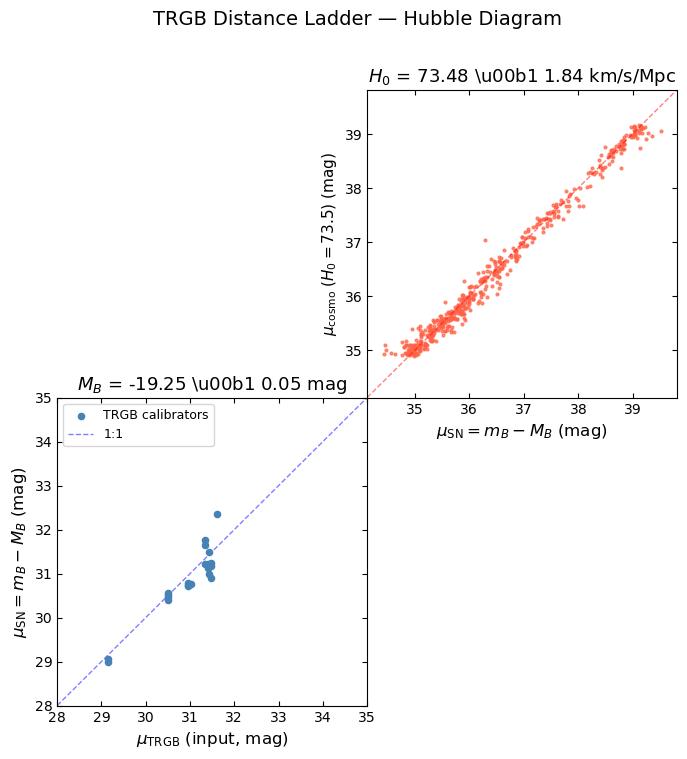

In [10]:
from astropy.cosmology import LambdaCDM

cosmo_trgb = LambdaCDM(H0=result_trgb['H0'], Om0=0.3, Ode0=0.7)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].axis('off')
axes[1, 1].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)

# ── Bottom-left: μ_TRGB vs μ_SN (calibrators) ─────────────────────────────
ax = axes[1, 0]
trgb_hosts = [(h, mu_host_trgb[h]) for h in merged_cal['host'].dropna().unique()
              if h in mu_host_trgb and not np.isnan(mu_host_trgb[h])]
if trgb_hosts:
    x_vals, y_vals = [], []
    for h, mu_in in trgb_hosts:
        rows = merged_cal[merged_cal['host'] == h]
        mu_sn = rows['m_b_corr'].values - result_trgb['M_B']
        x_vals.extend([mu_in] * len(mu_sn))
        y_vals.extend(mu_sn.tolist())
    ax.scatter(x_vals, y_vals, s=20, color='steelblue', zorder=3, label='TRGB calibrators')
mu_range = np.linspace(28, 35, 100)
ax.plot(mu_range, mu_range, 'b--', lw=1, alpha=0.5, label='1:1')
ax.set_xlabel(r'$\mu_\mathrm{TRGB}$ (input, mag)', fontsize=12)
ax.set_ylabel(r'$\mu_\mathrm{SN} = m_B - M_B$ (mag)', fontsize=12)
ax.set_title(fr'$M_B$ = {result_trgb["M_B"]:.2f} \u00b1 {result_trgb["sigma_M_B"]:.2f} mag', fontsize=13)
ax.set_xlim(28, 35); ax.set_ylim(28, 35)
ax.legend(fontsize=9)
ax.tick_params(direction='in', top=True, right=True)

# ── Top-right: μ_SN vs μ_cosmo (Hubble-flow) ──────────────────────────────
ax2 = axes[0, 1]
hf_mu  = merged_hf['m_b_corr'].values - result_trgb['M_B']
hf_z   = merged_hf['zHD'].values
mu_cos = cosmo_trgb.distmod(hf_z).value
lim    = [min(hf_mu.min(), mu_cos.min()) - 0.3, max(hf_mu.max(), mu_cos.max()) + 0.3]
ax2.scatter(hf_mu, mu_cos, s=4, color='tomato', alpha=0.7)
ax2.plot(lim, lim, 'r--', lw=1, alpha=0.5)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel(r'$\mu_\mathrm{SN} = m_B - M_B$ (mag)', fontsize=12)
ax2.set_ylabel(rf'$\mu_\mathrm{{cosmo}}\;(H_0={result_trgb["H0"]:.1f})$ (mag)', fontsize=11)
ax2.set_title(fr'$H_0$ = {result_trgb["H0"]:.2f} \u00b1 {result_trgb["sigma_H0"]:.2f} km/s/Mpc', fontsize=13)
ax2.tick_params(direction='in', top=True, right=True)

fig.suptitle('TRGB Distance Ladder \u2014 Hubble Diagram', fontsize=14, y=0.98)
plt.show()


### Sensitivity to a uniform TRGB zero-point shift

A global bias in your TRGB distances — for example from a systematic error in the NGC 4258 maser distance or the TRGB absolute calibration — shifts all host distances by the same amount Δμ. The slope dH₀/dΔμ ≈ −H₀ × ln(10)/5 ≈ −34 km/s/Mpc per magnitude, so a 0.01 mag bias moves H₀ by ~0.3 km/s/Mpc. This plot shows how much $H_0$ would change with various global biases.


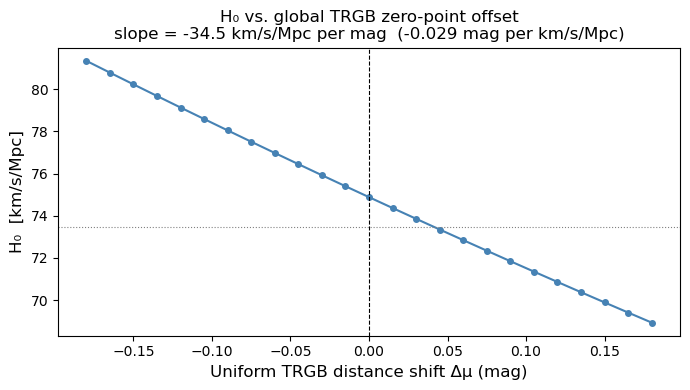

In [11]:
H0_base_trgb = result_trgb['H0']
shifts = np.linspace(-0.18, 0.18, 25)
H0_vals_trgb = []
for ds in shifts:
    mu_shifted = {h: (v + ds if not np.isnan(v) else np.nan)
                  for h, v in mu_host_trgb.items()}
    r = solve_H0(mu_shifted, y=y, C=C, labels=labels, verbose=False)
    H0_vals_trgb.append(r['H0'])

H0_vals_trgb = np.array(H0_vals_trgb)
slope_trgb = np.polyfit(shifts, H0_vals_trgb, 1)[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, H0_vals_trgb, 'o-', color='steelblue', markersize=4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(H0_base_trgb, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Uniform TRGB distance shift \u0394\u03bc (mag)', fontsize=12)
ax.set_ylabel('H\u2080  [km/s/Mpc]', fontsize=12)
ax.set_title(f'H\u2080 vs. global TRGB zero-point offset\n'
             f'slope = {slope_trgb:.1f} km/s/Mpc per mag  '
             f'({1/slope_trgb:.3f} mag per km/s/Mpc)')
plt.tight_layout()
plt.show()


---

## Appendix: SH0ES Cepheid Demonstration

This section runs the identical H₀ pipeline using **published SH0ES Cepheid distances** from
Riess et al. (2022), Table 6 — the same host galaxies measured with HST Cepheids.
It uses the original SH0ES R22 partial SN dataset (`data/SH0ES22_partial_*`), which covers
37 calibrator hosts and the SH0ES-selected Hubble-flow SNe.

The purpose is to let you compare your TRGB-based H₀ with the Cepheid-based H₀ using
the same solver, and to explore how sensitive H₀ is to shifts in the Cepheid distance scale.

> This section does not use your TRGB measurements — it is a fixed reference using
> published values.


In [12]:
# Load SH0ES R22 partial dataset for the appendix — separate from Part 1.
y_sh      = np.load('data/SH0ES22_partial_y.npy')
C_sh      = np.load('data/SH0ES22_partial_C.npy')
labels_sh = pd.read_csv('data/SH0ES22_partial_labels.csv')

cal_sh = labels_sh[labels_sh['type'] == 'CAL']
hf_sh  = labels_sh[labels_sh['type'] == 'HF']
print(f'SH0ES partial: {len(cal_sh)} calibrator obs, {len(hf_sh)} HF SNe, '
      f'{cal_sh["host"].nunique()} calibrator hosts.')


SH0ES partial: 75 calibrator obs, 277 HF SNe, 37 calibrator hosts.


### SH0ES Cepheid distances

The dict `mu_host` maps each host to its Cepheid distance modulus from Table 6 of Riess et al. (2022).
`sigma_mu_host` gives the 1σ per-host distance uncertainty.

Uncomment lines in the next cell to explore how H₀ changes when individual host distances are adjusted.


In [13]:
mu_host_unique = [
    29.178, 32.920, 34.527, 32.830, 33.709, 32.563, 32.541, 31.378,
    31.287, 31.491, 31.450, 32.051, 32.612, 32.464, 33.014, 32.331,
    32.120, 31.936, 32.804, 31.635, 31.722, 31.603, 30.844, 30.835,
    31.812, 32.599, 33.116, 31.772, 30.546, 33.094, 32.223, 32.363,
    31.628, 33.246, 32.500, 33.187, 32.848
]

sigma_host_unique = [
    0.041, 0.123, 0.250, 0.109, 0.149, 0.074, 0.059, 0.056,
    0.037, 0.061, 0.064, 0.099, 0.154, 0.158, 0.165, 0.076,
    0.051, 0.034, 0.080, 0.089, 0.071, 0.116, 0.128, 0.050,
    0.084, 0.205, 0.074, 0.052, 0.205, 0.099, 0.120, 0.125,
    0.117, 0.119, 0.153, 0.067
]

Host_unique = [
    "M101", "M1337", "N105A", "N0691", "N976A", "N1015", "N1309", "N1365",
    "N1448", "N1559", "N2442", "N2525", "N2608", "N3021", "N3147", "N3254",
    "N3370", "N3447", "N3583", "N3972", "N3982", "N4038", "N4424", "N4536",
    "N4639", "N4680", "N5468", "N5584", "N5643", "N5728", "N5861", "N5917",
    "N7250", "N7329", "N7541", "N7678", "U9391"
]

mu_host       = {h.lower(): mu    for h, mu    in zip(Host_unique, mu_host_unique)}
sigma_mu_host = {h.lower(): sigma for h, sigma in zip(Host_unique, sigma_host_unique)}


In [14]:
# Optional: modify individual host distances to explore the effect on H₀.
mu_host_modified       = mu_host.copy()
sigma_mu_host_modified = sigma_mu_host.copy()

# Uncomment any line below to adjust a specific host:
#mu_host_modified['n5584'] = mu_host_modified['n5584'] + 0.1
#mu_host_modified['n3370'] = mu_host_modified['n3370'] - 0.2
#mu_host_modified['n3447'] = 31.0          # override to a fixed value
#mu_host_modified['n2525'] = np.nan        # remove a host from the fit
#sigma_mu_host_modified['n2442'] = 0.3     # inflate a host uncertainty


### Solve for H₀


In [15]:
# NOTE: uncertainty does not account for covariance between host distances.
print('*** R22 Cepheid distances (as published) ***')
result_sh = solve_H0(mu_host, sigma_mu_host=sigma_mu_host,
                     y=y_sh, C=C_sh, labels=labels_sh)

print('\n*** Modified distances ***')
result_sh_mod = solve_H0(mu_host_modified, sigma_mu_host=sigma_mu_host_modified,
                         y=y_sh, C=C_sh, labels=labels_sh)


*** R22 Cepheid distances (as published) ***
M_B       = -19.2498 ± 0.0218  mag
H0        = 73.1553 ± 0.7825  km/s/Mpc
chi2/dof  = 307.6/350 = 0.879

*** Modified distances ***
M_B       = -19.2498 ± 0.0218  mag
H0        = 73.1553 ± 0.7825  km/s/Mpc
chi2/dof  = 307.6/350 = 0.879


### Hubble diagram (Cepheid calibration)


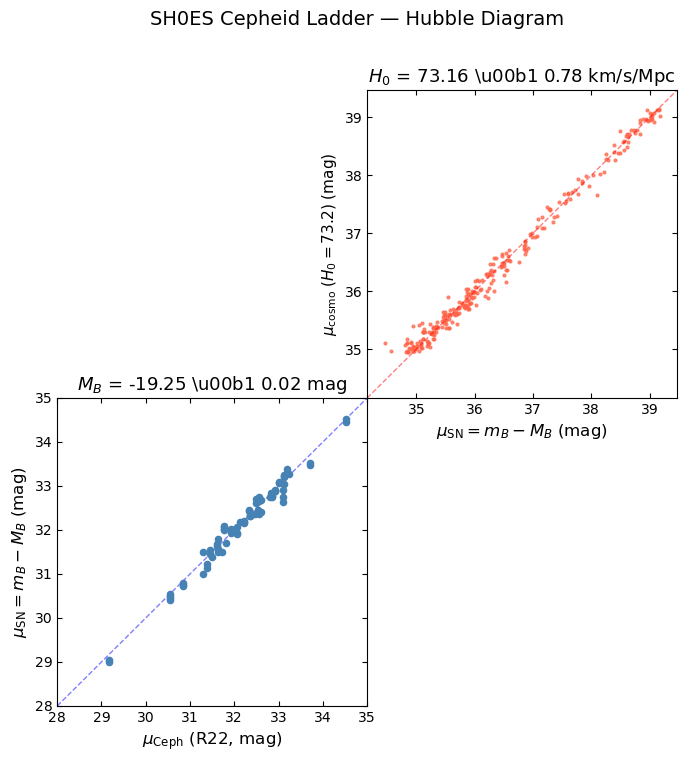

In [16]:
# Cross-match SH0ES labels with Pantheon+ for redshifts.
labels_sh_plot = labels_sh.copy()
for i in labels_sh_plot.index:
    label = labels_sh_plot.at[i, 'label']
    if not isinstance(label, str):
        continue
    parts = label.split('_')
    if len(parts) == 2:
        labels_sh_plot.at[i, 'CID'] = parts[0]
        labels_sh_plot.at[i, 'IDSURVEY'] = parts[1]
    elif len(parts) == 3:
        labels_sh_plot.at[i, 'CID'] = parts[1]
        labels_sh_plot.at[i, 'IDSURVEY'] = parts[2]

labels_sh_plot['key'] = (labels_sh_plot['CID'].astype(str) + '_' +
                         labels_sh_plot['IDSURVEY'].astype(str))
merged_sh = pd.merge(
    pplus[['key', 'zHD', 'm_b_corr']],
    labels_sh_plot[['key', 'host', 'type']],
    on='key', how='inner'
)
merged_sh_hf  = merged_sh[merged_sh['type'] == 'HF']
merged_sh_cal = merged_sh[merged_sh['type'] == 'CAL']

cosmo_sh = LambdaCDM(H0=result_sh['H0'], Om0=0.3, Ode0=0.7)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].axis('off')
axes[1, 1].axis('off')
plt.subplots_adjust(wspace=0, hspace=0)

# ── Bottom-left: μ_Ceph vs μ_SN (calibrators) ─────────────────────────────
ax = axes[1, 0]
for h in merged_sh_cal['host'].dropna().unique():
    if h not in mu_host:
        continue
    rows = merged_sh_cal[merged_sh_cal['host'] == h]
    mu_sn = rows['m_b_corr'].values - result_sh['M_B']
    ax.scatter([mu_host[h]] * len(mu_sn), mu_sn, s=20, color='steelblue', zorder=3)
mu_range = np.linspace(28, 35, 100)
ax.plot(mu_range, mu_range, 'b--', lw=1, alpha=0.5, label='1:1')
ax.set_xlabel(r'$\mu_\mathrm{Ceph}$ (R22, mag)', fontsize=12)
ax.set_ylabel(r'$\mu_\mathrm{SN} = m_B - M_B$ (mag)', fontsize=12)
ax.set_title(fr'$M_B$ = {result_sh["M_B"]:.2f} \u00b1 {result_sh["sigma_M_B"]:.2f} mag', fontsize=13)
ax.set_xlim(28, 35); ax.set_ylim(28, 35)
ax.tick_params(direction='in', top=True, right=True)

# ── Top-right: μ_SN vs μ_cosmo (Hubble-flow) ──────────────────────────────
ax2 = axes[0, 1]
hf_mu_sh  = merged_sh_hf['m_b_corr'].values - result_sh['M_B']
hf_z_sh   = merged_sh_hf['zHD'].values
mu_cos_sh = cosmo_sh.distmod(hf_z_sh).value
lim_sh = [min(hf_mu_sh.min(), mu_cos_sh.min()) - 0.3,
           max(hf_mu_sh.max(), mu_cos_sh.max()) + 0.3]
ax2.scatter(hf_mu_sh, mu_cos_sh, s=4, color='tomato', alpha=0.7)
ax2.plot(lim_sh, lim_sh, 'r--', lw=1, alpha=0.5)
ax2.set_xlim(lim_sh); ax2.set_ylim(lim_sh)
ax2.set_xlabel(r'$\mu_\mathrm{SN} = m_B - M_B$ (mag)', fontsize=12)
ax2.set_ylabel(rf'$\mu_\mathrm{{cosmo}}\;(H_0={result_sh["H0"]:.1f})$ (mag)', fontsize=11)
ax2.set_title(fr'$H_0$ = {result_sh["H0"]:.2f} \u00b1 {result_sh["sigma_H0"]:.2f} km/s/Mpc', fontsize=13)
ax2.tick_params(direction='in', top=True, right=True)

fig.suptitle('SH0ES Cepheid Ladder \u2014 Hubble Diagram', fontsize=14, y=0.98)
plt.show()


### Sensitivity to a uniform Cepheid zero-point shift


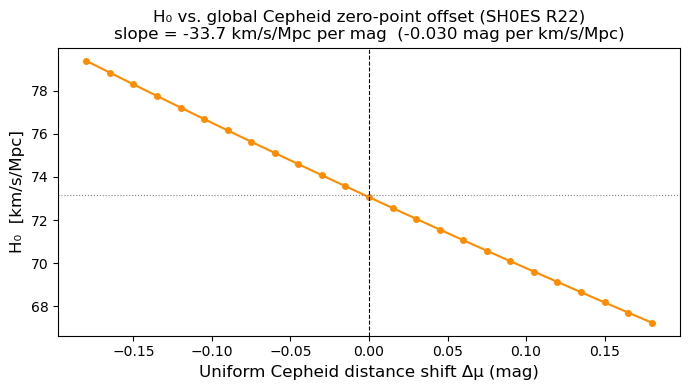

In [17]:
H0_base_sh = result_sh['H0']
H0_vals_sh = []
for ds in shifts:
    mu_shifted = {h: v + ds for h, v in mu_host.items()}
    r = solve_H0(mu_shifted, y=y_sh, C=C_sh, labels=labels_sh, verbose=False)
    H0_vals_sh.append(r['H0'])

H0_vals_sh = np.array(H0_vals_sh)
slope_sh = np.polyfit(shifts, H0_vals_sh, 1)[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, H0_vals_sh, 'o-', color='darkorange', markersize=4)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(H0_base_sh, color='gray', lw=0.8, ls=':')
ax.set_xlabel('Uniform Cepheid distance shift \u0394\u03bc (mag)', fontsize=12)
ax.set_ylabel('H\u2080  [km/s/Mpc]', fontsize=12)
ax.set_title(f'H\u2080 vs. global Cepheid zero-point offset (SH0ES R22)\n'
             f'slope = {slope_sh:.1f} km/s/Mpc per mag  '
             f'({1/slope_sh:.3f} mag per km/s/Mpc)')
plt.tight_layout()
plt.show()
